# LLH Model Calibration to S&P 500 Options

Calibrate the 7 LLH parameters $\Theta = (\kappa, \nu, \lambda, \eta, \rho, \sigma_0, \theta_0)$ by minimizing **relative MSE** between MC model prices and market mid-prices: $\text{RelMSE} = \frac{1}{N}\sum_i \left(\frac{\hat V_i - V_{\text{market},i}}{V_{\text{market},i}}\right)^2$. This normalization prevents expensive options from dominating the loss.

**Method:** Differential Evolution (global) → L-BFGS-B (local refinement), with Common Random Numbers for a smooth objective.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import calibrate as cal
import priceModels as pm

%matplotlib inline

## 1. Fetch S&P 500 options data and risk-free rate

In [2]:
spot, r, raw_df = cal.fetch_spx_options("^SPX")
print(f"Spot: {spot:.2f}")
print(f"Risk-free rate (cc): {r:.4f}")
print(f"Raw options: {len(raw_df)} contracts across {raw_df['tau'].nunique()} expirations")
raw_df.head()

Spot: 6506.48
Risk-free rate (cc): 0.0355
Raw options: 15563 contracts across 48 expirations


,strike,bid,ask,volume,openInterest,impliedVolatility,tau,option_type,mid_price
0,5500.0,1033.1,1043.1,1.0,1.0,1.386783,0.005479,call,1038.10
1,6000.0,537.1,540.0,1.0,8001.0,0.816606,0.005479,call,538.55
2,6175.0,360.1,368.5,NaN,2.0,0.613133,0.005479,call,364.30
3,6200.0,335.5,343.7,5.0,2.0,0.584294,0.005479,call,339.60
4,6250.0,285.8,294.1,1.0,1.0,0.523702,0.005479,call,289.95


## 2. Filter to liquid, near-the-money OTM options

In [3]:
df = cal.filter_options(raw_df, spot)
print(f"Filtered: {len(df)} options across {df['tau'].nunique()} maturities")
print(f"  Calls: {(df['option_type']=='call').sum()}, Puts: {(df['option_type']=='put').sum()}")
print(f"  Moneyness range: [{df['strike'].min()/spot:.3f}, {df['strike'].max()/spot:.3f}]")
print(f"  Maturity range:  [{df['tau'].min():.4f}, {df['tau'].max():.4f}] years")
df.head(10)

Filtered: 1420 options across 33 maturities
  Calls: 715, Puts: 705
  Moneyness range: [0.853, 1.149]
  Maturity range:  [0.0438, 0.9945] years


,strike,bid,ask,volume,openInterest,impliedVolatility,tau,option_type,mid_price
0,6570.0,109.6,112.5,43.0,410.0,0.252273,0.043836,call,111.05
1,6625.0,81.1,83.3,113.0,101.0,0.237629,0.043836,call,82.20
2,6700.0,49.1,50.7,159.0,174.0,0.218498,0.043836,call,49.90
3,6710.0,45.4,47.0,350.0,494.0,0.215977,0.043836,call,46.20
4,6730.0,38.7,40.1,18.0,122.0,0.211018,0.043836,call,39.40
5,6750.0,32.5,33.8,71.0,149.0,0.206017,0.043836,call,33.15
6,6760.0,29.5,30.9,33.0,190.0,0.203560,0.043836,call,30.20
7,6775.0,25.1,26.9,77.0,164.0,0.200039,0.043836,call,26.00
8,6780.0,23.8,25.6,59.0,220.0,0.198754,0.043836,call,24.70
9,6800.0,19.2,20.9,466.0,666.0,0.193940,0.043836,call,20.05


## 3. Calibrate

Two-stage optimization: Differential Evolution (global search) followed by L-BFGS-B (local refinement). Common Random Numbers ensure a smooth, deterministic objective.

In [4]:
%%time
result = cal.calibrate(spot, r, df, n_paths=10_000, seed=42)

Calibrating: 1420 options, T_max=0.9945yr, n_steps_mc=251, n_paths=10000
Stage A: Differential Evolution...
  DE gen  10: RelMSE = 0.170183
  DE gen  20: RelMSE = 0.132116
  DE gen  30: RelMSE = 0.122777
  DE gen  40: RelMSE = 0.120233
  DE gen  50: RelMSE = 0.120088
  DE done: RelMSE = 0.120088
Stage B: L-BFGS-B refinement...
  L-BFGS-B done: RelMSE = 0.119097

Calibrated parameters:
  kappa    = 1.388850
  nu       = 0.096607
  lam      = -0.528833
  eta      = 0.715534
  rho      = -0.984720
  sigma0   = 0.194553
  theta0   = 0.312922

Final RelMSE = 0.119097  (RRMSE = 34.51%)
CPU times: user 10min 25s, sys: 2min 15s, total: 12min 41s
Wall time: 12min 41s


## 4. Evaluate calibrated model (50K paths) and report

In [7]:
eval_df = cal.report_calibration(result, spot, r, df, n_paths=50_000)
eval_df.describe()

Evaluation (50,000 paths): RMSE=$62.20, MAE=$35.48, MAPE=28.7%


,strike,tau,moneyness,market_price,model_price,error,pct_error,market_iv,model_iv
count,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000,1420.000000
mean,6550.380282,0.262161,1.006747,113.599507,106.116648,-7.482859,-11.336590,0.221167,0.205217
std,513.316981,0.266986,0.078893,114.036755,124.622706,61.770822,33.001666,0.052881,0.052852
min,5550.000000,0.043836,0.852996,0.500000,0.116747,-298.990414,-98.378518,0.143531,0.097122
25%,6125.000000,0.073973,0.941369,23.262500,14.051372,-20.928553,-34.642630,0.172269,0.161418
50%,6550.000000,0.131507,1.006689,77.400000,58.141595,-5.426112,-11.499146,0.218148,0.174757
75%,7000.000000,0.361644,1.075851,172.450000,151.178833,1.653061,14.761191,0.255321,0.243541
max,7475.000000,0.994521,1.148855,649.500000,733.270867,291.720867,66.067459,0.405317,0.333659


## 5. Diagnostic plots

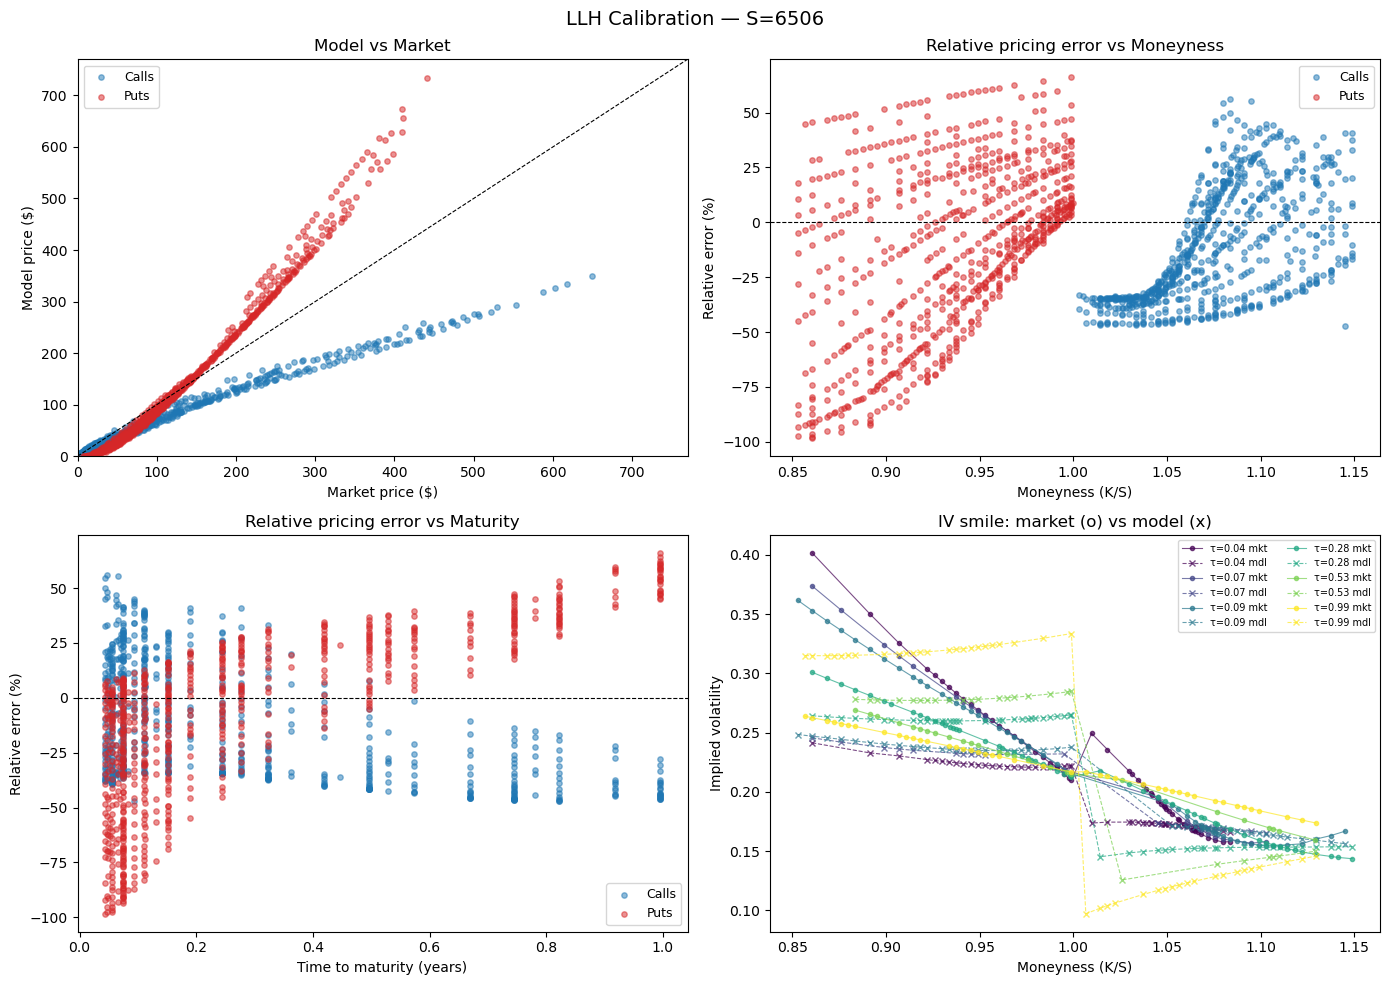

In [8]:
cal.plot_calibration(eval_df, spot)

## 6. Smoke test: round-trip with known parameters

Generate synthetic option prices with LLH Table 2 params (500K paths), then calibrate back and check recovery.

In [9]:
# Ground truth: LLH Table 2 parameters
true_params = [4.9394, 0.4, 0.3115, 0.4112, 0.1691, 0.2924, 0.1319]
r_synth = 0.05
S0 = 100.0

# Generate synthetic option grid
strikes = [90, 95, 100, 105, 110]
taus = [0.1, 0.25, 0.5, 0.75]
rows = []
for tau in taus:
    for K in strikes:
        for otype in ["call", "put"]:
            rows.append({"strike": K, "tau": tau, "option_type": otype, "mid_price": 0.0})
synth_df = pd.DataFrame(rows)

# Price with 500K paths (high accuracy "true" prices)
from math import ceil
T_max = max(taus)
n_steps_synth = max(1, ceil(T_max * 252))
draws_synth = cal.generate_random_draws(500_000, n_steps_synth, seed=99)
S_true = cal._simulate_from_draws(true_params, r_synth, S0, T_max, draws_synth)
dt_synth = T_max / n_steps_synth

for i, row in synth_df.iterrows():
    j = max(1, min(n_steps_synth, round(row["tau"] / dt_synth)))
    S_T = S_true[:, j]
    disc = np.exp(-r_synth * row["tau"])
    K = row["strike"]
    if row["option_type"] == "call":
        synth_df.loc[i, "mid_price"] = disc * np.maximum(S_T - K, 0.0).mean()
    else:
        synth_df.loc[i, "mid_price"] = disc * np.maximum(K - S_T, 0.0).mean()

# Drop near-zero prices
synth_df = synth_df[synth_df["mid_price"] > 0.05].reset_index(drop=True)
print(f"Synthetic options: {len(synth_df)}")
synth_df.head()

Synthetic options: 40


,strike,tau,option_type,mid_price
0,90,0.1,call,11.390802
1,90,0.1,put,0.304234
2,95,0.1,call,7.164333
3,95,0.1,put,1.052827
4,100,0.1,call,3.926763


In [10]:
%%time
# Calibrate back from synthetic prices
result_synth = cal.calibrate(
    S0, r_synth, synth_df,
    n_paths=10_000, seed=42,
    de_maxiter=50, de_popsize=15
)

Calibrating: 40 options, T_max=0.7500yr, n_steps_mc=189, n_paths=10000
Stage A: Differential Evolution...
  DE gen  10: RelMSE = 0.007297
  DE gen  20: RelMSE = 0.002236
  DE gen  30: RelMSE = 0.001636
  DE gen  40: RelMSE = 0.000721
  DE gen  50: RelMSE = 0.000267
  DE done: RelMSE = 0.000267
Stage B: L-BFGS-B refinement...
  L-BFGS-B done: RelMSE = 0.000140

Calibrated parameters:
  kappa    = 6.906385
  nu       = 0.469647
  lam      = -0.249636
  eta      = 0.574929
  rho      = 0.143147
  sigma0   = 0.287094
  theta0   = 0.189237

Final RelMSE = 0.000140  (RRMSE = 1.18%)
CPU times: user 5min 58s, sys: 1min 41s, total: 7min 40s
Wall time: 7min 40s


In [9]:
# Compare recovered vs true parameters
print(f"{'Param':>8s}  {'True':>8s}  {'Recovered':>10s}  {'Error':>8s}")
print("-" * 42)
for name, true_val, rec_val in zip(cal.PARAM_NAMES, true_params, result_synth["params_array"]):
    print(f"{name:>8s}  {true_val:8.4f}  {rec_val:10.4f}  {rec_val - true_val:+8.4f}")

   Param      True   Recovered     Error
------------------------------------------
   kappa    4.9394      4.5289   -0.4105
      nu    0.4000      0.4849   +0.0849
     lam    0.3115      0.4652   +0.1537
     eta    0.4112      0.2937   -0.1175
     rho    0.1691      0.1483   -0.0208
  sigma0    0.2924      0.2954   +0.0030
  theta0    0.1319      0.0931   -0.0388
